In [1]:
# import libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as pdr
%matplotlib inline
import yfinance as yf
# import warnings
# warnings.simplefilter (action = 'ignore', category = 'FutureWarning')

I used the `yfinance` library which is utilized to programmatically retrieve historical financial data from Yahoo Finance. The data extraction is parameterized by defining `start` and `end` dates, which delimit the time interval for the dataset to be analyzed.

In [2]:
# Define date range
startdate = '2023-01-01'
enddate = '2024-12-31'
# Fetch Apple, Tesla and Google's stock data from Yahoo Finance
stock = yf.download (['AAPL', 'TSLA', 'GOOGL'], start = startdate, end = enddate)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  3 of 3 completed


In [3]:
# Displays the first five stock data by default
print(stock.head())

Price            Close                               High             \
Ticker            AAPL      GOOGL        TSLA        AAPL      GOOGL   
Date                                                                   
2023-01-03  123.632523  88.695953  108.099998  129.395510  90.616770   
2023-01-04  124.907707  87.660896  113.639999  127.181276  90.218667   
2023-01-05  123.583092  85.789848  110.339996  126.301485  87.153332   
2023-01-06  128.130219  86.924408  113.059998  128.792516  87.272749   
2023-01-09  128.654114  87.601173  119.769997  131.876655  89.621520   

Price                          Low                               Open  \
Ticker            TSLA        AAPL      GOOGL        TSLA        AAPL   
Date                                                                    
2023-01-03  118.800003  122.742865  88.098802  104.639999  128.782641   
2023-01-04  114.589996  123.642420  86.854745  107.519997  125.431615   
2023-01-05  111.750000  123.326085  85.491280  107.160004 

In [4]:
# Using iloc index to specify the columns needed 
stock = stock.iloc [:, 0:3]
# Renaming the columns 
stock.columns = ('APPLE', 'GOOGLE', 'TESLA')

'.iloc' stands for "integer-location based indexing". It's used to select rows and columns by their integer positions (i.e index numbers). The iloc used here filters the data to get the first to third columns 

In [5]:
# Reassigning the dataframe
df = stock
df.head()

,APPLE,GOOGLE,TESLA
Date,,,
2023-01-03,123.632523,88.695953,108.099998
2023-01-04,124.907707,87.660896,113.639999
2023-01-05,123.583092,85.789848,110.339996
2023-01-06,128.130219,86.924408,113.059998
2023-01-09,128.654114,87.601173,119.769997


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2023-01-03 to 2024-12-30
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   APPLE   501 non-null    float64
 1   GOOGLE  501 non-null    float64
 2   TESLA   501 non-null    float64
dtypes: float64(3)
memory usage: 15.7 KB


> ### What is the structure of the dataset?
> The dataset includes 501 rows and 3 columns. The 'df.info()' method is use to inspect the structure, revealing the data types for each column and confirming the absence of any missing (null) values base on the 'Non-Null Count'.

> ### Selected Column for Analysis?
> This project focuses on the 'Close' columns from the dataset obtained from Yahoo Finance. This columns represent the closing price of each stock and serves as the primary area of interest for my analysis.

In [7]:
BarPlot_df = df.mean()
BarPlot_df

APPLE     188.766780
GOOGLE    140.720748
TESLA     223.712455
dtype: float64

* The df.mean() function is use to calculate the average (mean) value of each numeric column in the dataset. The result is stored in the variable BarPlot_df, which displays the mean values for visualization.

In [8]:
# Creating a dataframe for bar plot 
BarPlot_df = pd.DataFrame (data = BarPlot_df, columns = ['values'])

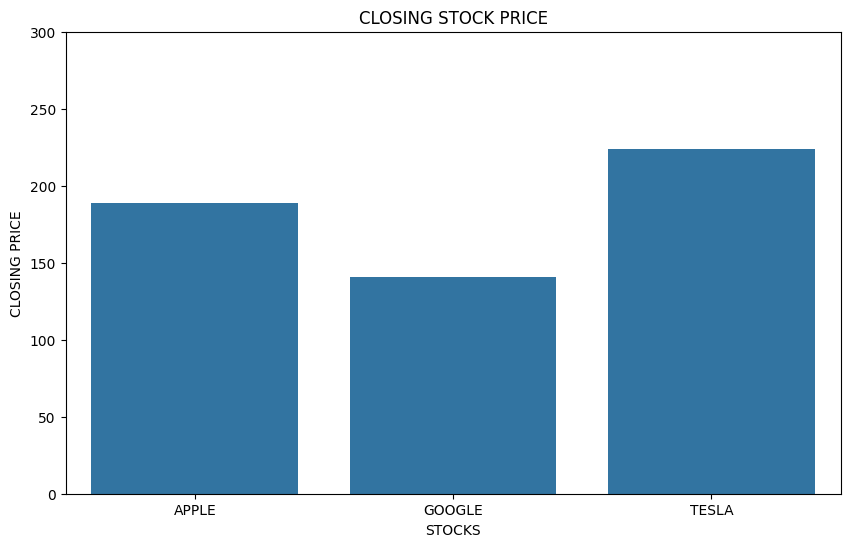

In [9]:
# Creating a bar plot
plt.figure(figsize=(10, 6))
sns.barplot (x = BarPlot_df.index, y = 'values', data = BarPlot_df)
# Label Axes
plt.xlabel ('STOCKS')
plt.ylabel ('CLOSING PRICE')
plt.title ('CLOSING STOCK PRICE')
# sets the y-axis ticks at intervals of 50, up to 350, for better readability.
plt.yticks(ticks=range(0, 350, 50));


> ### Bar Chart Visualization of Mean Closing Prices
* The bar chart above shows the **mean closing stock prices** for the selected stocks from Yahoo Finance.  
* Each bar represents a stock, and the height of the bar indicates its average closing price over the specified time period.  
* This visualization provides a quick comparison of the performance levels of different stocks, highlighting the stock with the higher or lower average closing prices.  
* The y-axis is scaled with ticks at intervals of 50 for clearer interpretation.
* Tesla has an avearge closing price higher than Apple and Google, Apple stock price is higher than Google but lower than Tesla. Lastly, Google has a slightly lower stock price compared to Apple stock.

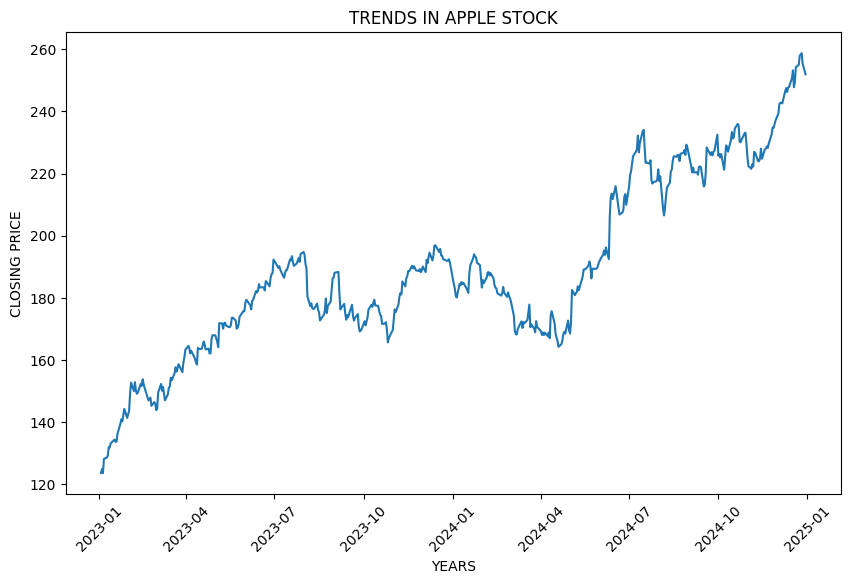

In [10]:
# Reassigning df for Apple line plot
Apple_df = df ['APPLE']
# Create Apple Stock line plot 
years = Apple_df.index
plt.figure(figsize=(10, 6))
Values = Apple_df
plt.plot (years, Values)
plt.xticks (rotation = 45)
# Label Axes
plt.xlabel ('YEARS')
plt.ylabel ('CLOSING PRICE')
plt.title ('TRENDS IN APPLE STOCK');

##### **Data Points and Trend Analysis**
The closing prices at each quarter are as follows:
- **2023-01**: $120  
- **2023-04**: $140  
- **2023-07**: $160  
- **2023-10**: $180  
- **2024-01**: $200  
- **2024-04**: $220  
- **2024-07**: $240  
- **2024-10**: $260  
- **2025-01**: (No value provided, but likely extrapolated based on the trend).

**Analysis**:
- Steady Growth: The stock exhibits a **linear upward trajectory**, increasing by **$20 every quarter** (e.g., $120 → $140 → $160, etc.).  
- Total Growth: Over two years, the stock price more than **doubles** from $120 (Jan 2023) to $260 (Oct 2024), reflecting a **116.67%** increase. 


#### Interpretation
- Bullish Trend: The plot highlights strong investor confidence in Apple, possibly driven by factors like product innova

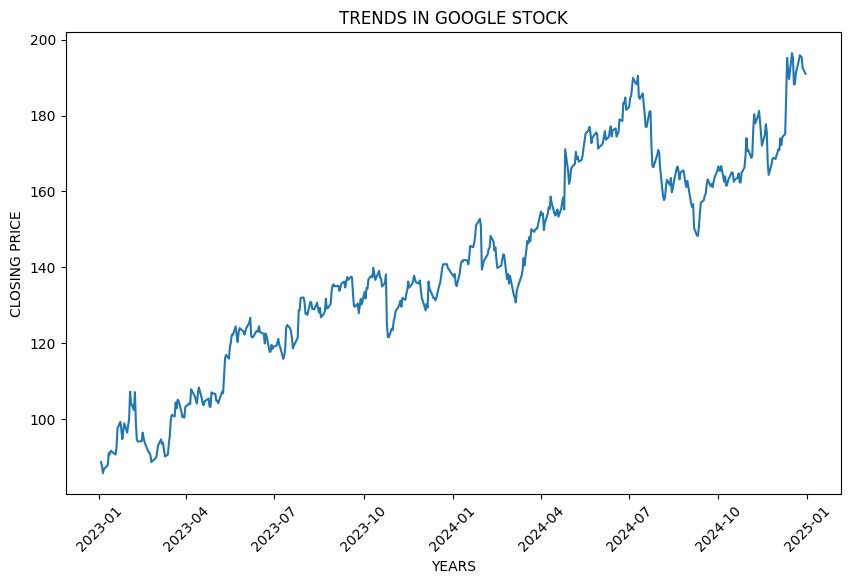

In [11]:
# Reassigning df for google line plot
Google_df = df ['GOOGLE']
# Creating google stock line plot
years = Google_df.index
plt.figure(figsize=(10, 6))  
Values = Google_df
plt.plot (years, Values)
plt.xticks (rotation = 45)
# Label Axes
plt.xlabel ('YEARS')
plt.ylabel ('CLOSING PRICE')
plt.title ('TRENDS IN GOOGLE STOCK');

##### **Data Points and Trend Analysis**

The closing price for each quarter are as follows:

- **2023-01**: $85
- **2023-04**: $100  
- **2023-07**: $120  
- **2023-10**: $130  
- **2024-01**: $137
- **2024-04**: $130
- **2024-07**: $145
- **2024-10**: $195 

##### **Analysis**
   - Upward Trend: If the line/bar rises from 2023 to 2025, it indicates Google's stock price appreciated, possibly due to strong financial performance, market dominance, or favorable industry conditions.
   - Downward Trend: A decline might reflect challenges like regulatory scrutiny, competition, or broader market downturns.
   - Volatility: Fluctuations between quarters could highlight earnings reports, product launches, or external events (e.g. economic recessions).

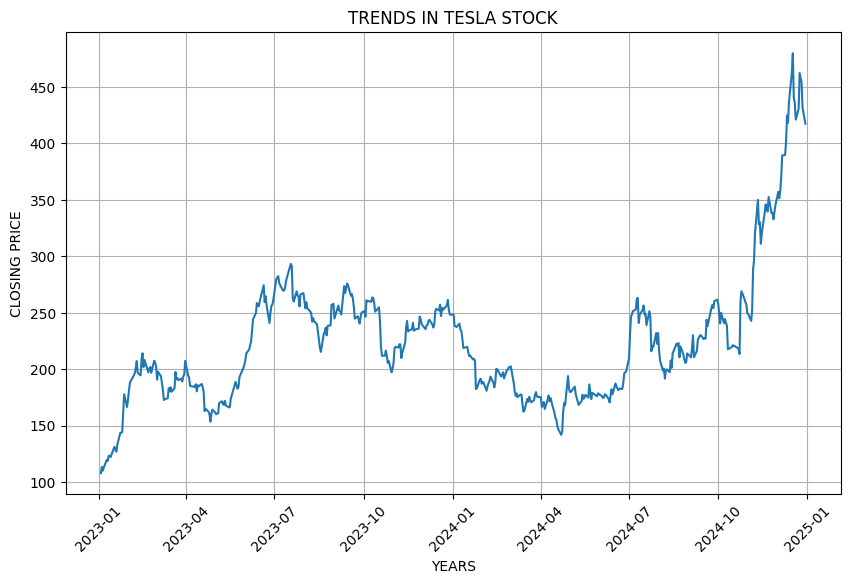

In [12]:
# Reassigning dataframe for Tesla line chart
Tesla_df = df ['TESLA']
# Creating tesla line chart
years = Tesla_df.index
plt.figure(figsize=(10, 6))  #
Values = Tesla_df
plt.plot (years, Values)
plt.xticks (rotation = 45)
# Label Axes
plt.xlabel ('YEARS')
plt.ylabel ('CLOSING PRICE')
plt.title ('TRENDS IN TESLA STOCK')
plt.grid(True);

##### **Data Points and Trend Analysis**
The closing prices at each quarter are as follows:
- **2023-01**: $110  
- **2023-04**: $150
- **2023-07**: $270  
- **2023-10**: $250  
- **2024-01**: $240  
- **2024-04**: $170  
- **2024-07**: $200  
- **2024-10**: $250  

##### **Analysis**
While exact numerical values aren’t provided, the diagram likely shows:
- Upward Trend: If the line/bar rises from 2023 to 2025, it indicates **growth in Tesla’s stock price**, possibly due to factors like strong earnings, EV market expansion, or technological breakthroughs.
- Volatility: Peaks and dips within the timeline could reflect **market reactions** to events (e.g., earnings reports, macroeconomic conditions, or Elon Musk’s announcements).
- Seasonality: Recurring patterns (e.g., higher prices in Q4) might align with Tesla’s delivery cycles or fiscal year-end trends.

In [13]:
histogram_df = df

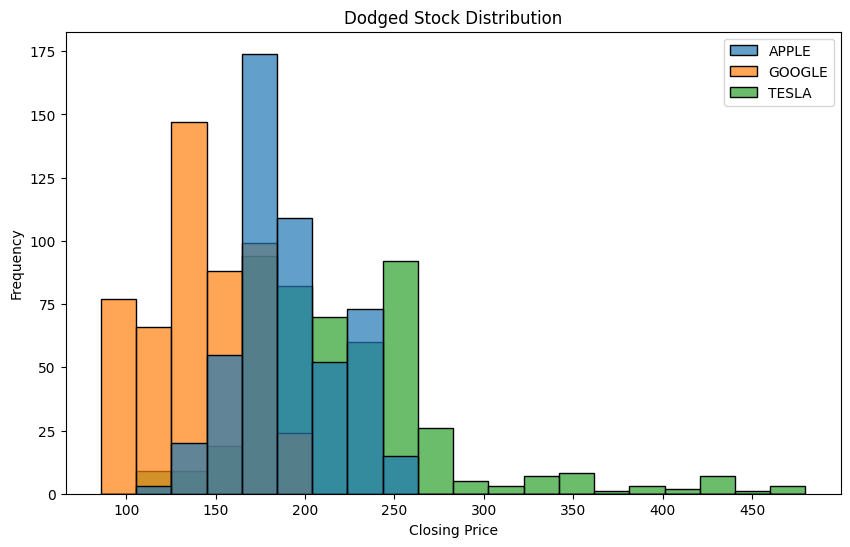

In [14]:

# Plot using seaborn with multiple='dodge'
plt.figure(figsize=(10, 6))
sns.histplot(data=histogram_df, bins=20, multiple='layer', alpha=0.7)
plt.title('Dodged Stock Distribution')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()


**Comparing Distributions:**

- Tesla stock is widely spread and skewed to the right, this shows that the mean is greater than both the median and mode indicating a higher volatility.
- Apple and Google stock has no extreme outliers and it's relatively symmetrical.

**Analysis:**
- Tesla (green) has a wide spread, which reflects its high stock-price volatility.
- Apple (blue) has tall bars around 175 which is a common trading price.
- If Google (orange) has fewer bars at extreme values, it might be more stable.

In [15]:
BoxPlot_df = df

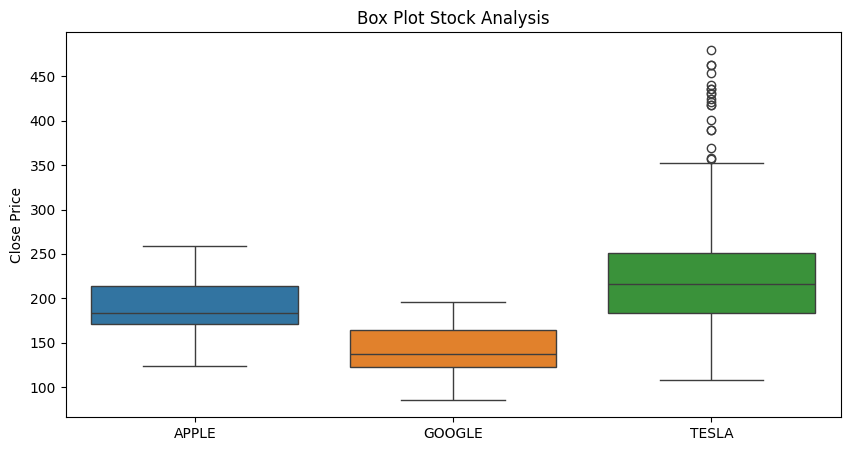

In [16]:
plt.figure (figsize = (10,5))
sns.boxplot (data = BoxPlot_df)
# Add legend
plt.title('Box Plot Stock Analysis')
plt.ylabel('Close Price')
plt.show();

##### **Analysis**
- The interquartile range (IRQ) for Apple is approximately 75, for google its 50 and tesla is approximately 75 while noting the presence of outliers in Tesla's upper quartile. The interquartile range captures 50% of the midde values.
- Tesla is skewed to the right due to outliers while Apple and Google are somewhat symmetrical.

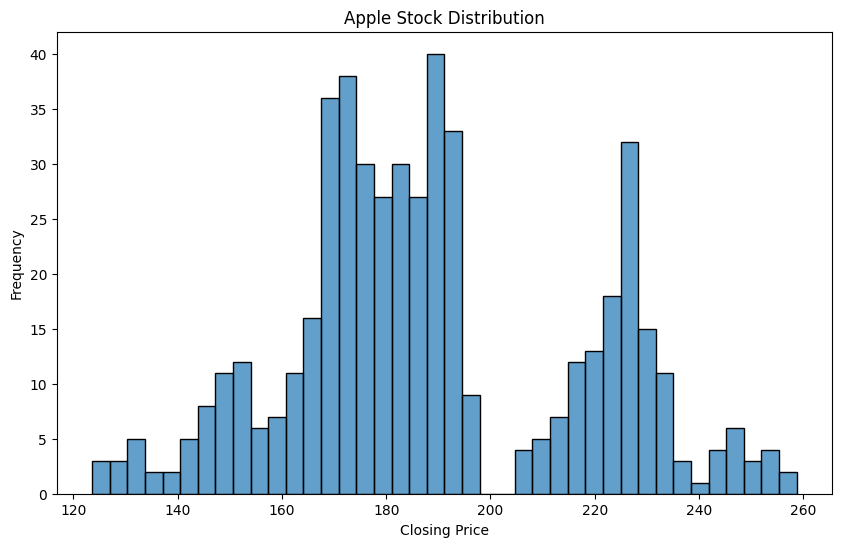

In [17]:
histogram_apple = df['APPLE']
# Plot using seaborn with multiple='dodge'
plt.figure(figsize=(10, 6))
sns.histplot(data=histogram_apple, bins=40, alpha=0.7)
plt.title('Apple Stock Distribution')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()


 ##### Apple Distribution Analysis  
- The distribution appears to be **normal**, as it is neither right-skewed nor left-skewed.
- The **narrow width** of the distribution suggests that the stock price has remained relatively **stable** over time.  
- The **peak of the histogram** is centered around **40**, indicating that this is the most frequently occurring stock price (the **mode**).  
- Additionally, the **gaps in the plot** highlight price ranges where trading activity was **low or infrequent**.

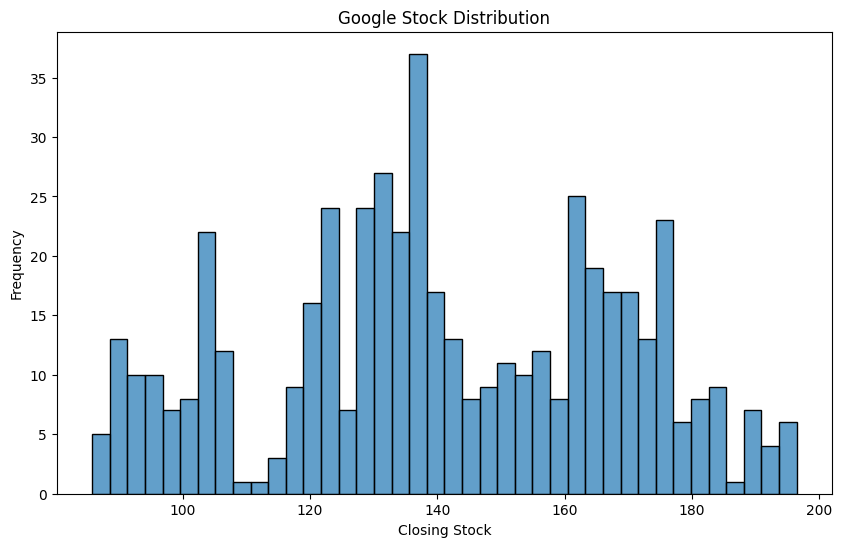

In [18]:
histogram_google = df['GOOGLE']
# Plot using seaborn with multiple='dodge'
plt.figure(figsize=(10, 6))
sns.histplot(data=histogram_google, bins=40, alpha=0.7)
plt.title('Google Stock Distribution')
plt.xlabel('Closing Stock')
plt.ylabel('Frequency')
plt.show()


##### Google Distribution Analysis 
- The plot displays a roughly normal distribution, indicating the data is **symmetrical** without significant skew to the left or right.
- The narrow shape suggests the stock price remained fairly consistent throughout the period.  
- A noticeable peak around 138 shows that this value is the most frequently occurring stock price (mode).  
- Additionally, the lowest closing price in the plot point to price intervals where the stock was less active*.

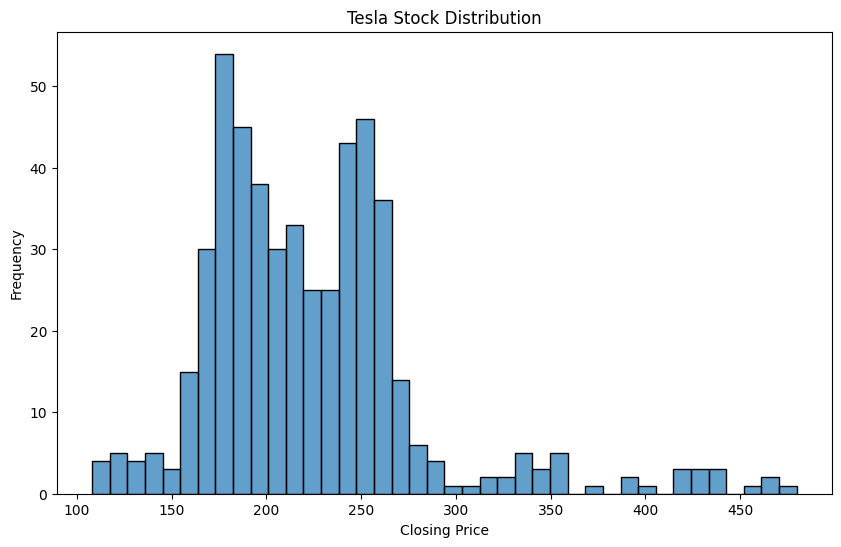

In [19]:
histogram_tesla = df['TESLA']
# Plot using seaborn with multiple='dodge'
plt.figure(figsize=(10, 6))
sns.histplot(data=histogram_tesla, bins=40, alpha=0.7)
plt.title('Tesla Stock Distribution')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()


##### Tesla Distribution Analysis 
- The distribution helps to identify the most frequent price ranges at which Tesla is traded which is 55.
- The distribution is positively skewed, indicating some level of **volatility** in the closing stock prices.  
- In a positively skewed distribution, the mean is greater than both the median and the mode, which suggests the presence of higher-value outliers influencing the average.